## PCA implementation

Image shape: (400, 64, 64)
Pixel range: 0.0 1.0


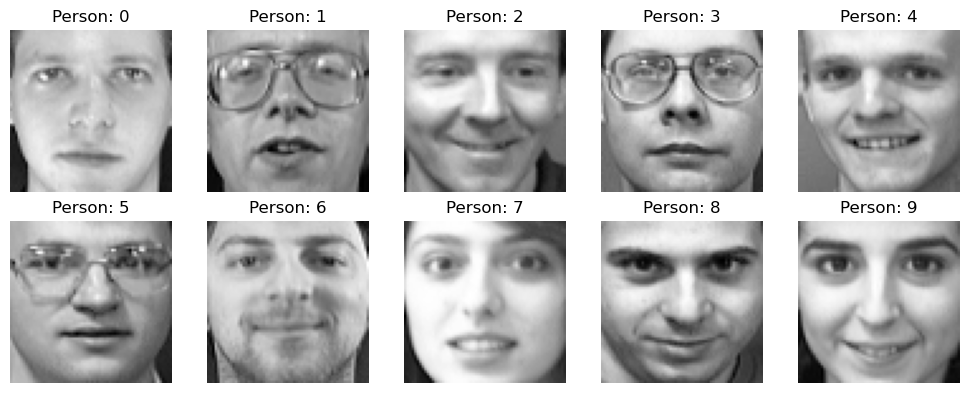

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
images = np.load("../data/olivetti_faces/olivetti_faces.npy")
targets = np.load("../data/olivetti_faces/olivetti_faces_target.npy")

print("Image shape:", images.shape)
print("Pixel range:", images.min(), images.max())

# Show some example images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

indices = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

for idx, ax in zip(indices, axes.flat):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"Person: {targets[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [50]:
def pca_images(images, k):
    # 1. Convert images to a 2D matrix
    # Each row = one image, each column = one pixel
    X = images.reshape(images.shape[0], -1)

    # Center the data
    mean_image = np.mean(X, axis=0)
    X_centered = X - mean_image

    # 2. Compute covariance matrix
    covariance_matrix = (
        X_centered.T @ X_centered
    ) / (X_centered.shape[0] - 1)

    # 3. Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # 4. Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # 5. Select the top k eigenvectors
    principal_components = eigenvectors[:, :k]

    # 6. Project images onto the lower-dimensional subspace
    X_projected = X_centered @ principal_components

    return (
        X,
        X_centered,
        mean_image,
        eigenvalues,
        principal_components,
        X_projected
    )

In [51]:
k = 50

X, X_centered, mean_image, eigenvalues, principal_components, X_projected = (
    pca_images(images, k)
)

print("Image matrix:", X.shape)
print("Principal components:", principal_components.shape)
print("Projected data:", X_projected.shape)

Image matrix: (400, 4096)
Principal components: (4096, 50)
Projected data: (400, 50)


## Reconstruction of images

In [ ]:
# Reconstruct the images
X_reconstructed = X_projected @ principal_components.T + mean_image

# Reshape the flattened images back to 64 x 64
reconstructed_images = X_reconstructed.reshape(images.shape)

print("Reconstructed images:", reconstructed_images.shape)

Reconstructed images: (400, 64, 64)


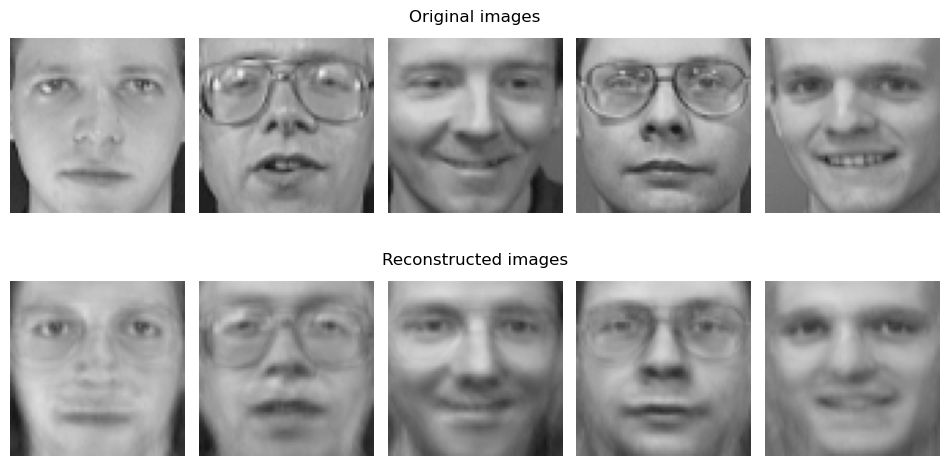

In [ ]:
# Visualize the original and reconstructed images
indices = [0, 10, 20, 30, 40]

fig, axes = plt.subplots(2, len(indices), figsize=(12, 5.5))

for i, idx in enumerate(indices):
    axes[0, i].imshow(images[idx], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed_images[idx], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 2].set_title("Original images", fontsize=12, pad=12)
axes[1, 2].set_title("Reconstructed images", fontsize=12, pad=12)

plt.subplots_adjust(hspace=0.35, wspace=0.08)
plt.show()

## Experimentation

## Visual Analysis

## Error Analysis